In [9]:
# ====
# Lab 4.2: Image Generation with Stable Diffusion
# Runs on Colab T4 (256x256 or 512x512)
# ====
!pip install diffusers transformers accelerate

import torch
from diffusers import StableDiffusionPipeline
from PIL import Image

# ====
# 1. CONFIG
# ====
MODEL_ID = "runwayml/stable-diffusion-v1-5" # or "stabilityai/stable-diffusion-2-1-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 256 # Use 512 for better quality if GPU allows

# ====
# 2. LOAD PIPELINE
# ====
print("Loading Stable Diffusion pipeline...")
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    safety_checker=None # disable safety checker for faster inference
)
pipe = pipe.to(DEVICE)

Loading Stable Diffusion pipeline...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [5]:
from google.colab import drive
import os
from IPython.display import display

drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/Modul 4 ML"
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive



Generating image 1/3: A serene mountain landscape at sunset, photorealistic, 4k


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/Colab Notebooks/Modul 4 ML/output_1.png


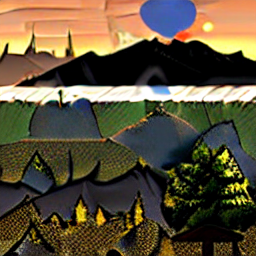


Generating image 2/3: A futuristic city with flying cars, neon lights, cyberpunk style


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/Colab Notebooks/Modul 4 ML/output_2.png


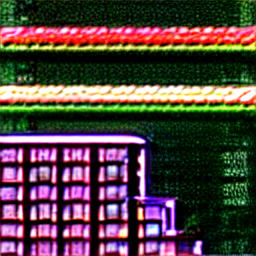


Generating image 3/3: A cat wearing a spacesuit floating in space, digital art


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/Colab Notebooks/Modul 4 ML/output_3.png


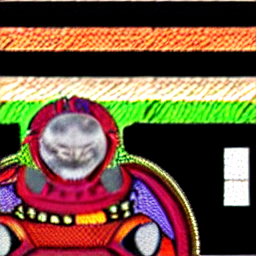

In [6]:
# ====
# 3. GENERATE IMAGES
# ====
prompts = [
    "A serene mountain landscape at sunset, photorealistic, 4k",
    "A futuristic city with flying cars, neon lights, cyberpunk style",
    "A cat wearing a spacesuit floating in space, digital art"
]

for i, prompt in enumerate(prompts):
    print(f"\nGenerating image {i+1}/{len(prompts)}: {prompt}")

    image = pipe(
        prompt=prompt,
        negative_prompt="blurry, low quality, distorted",
        height=IMG_SIZE,
        width=IMG_SIZE,
        num_inference_steps=30,
        guidance_scale=7.5,
        num_images_per_prompt=1,
        generator=torch.manual_seed(42),
    ).images[0]

    # Simpan ke folder Modul 4 ML
    filename = os.path.join(SAVE_DIR, f"output_{i+1}.png")
    image.save(filename)

    print(f"✅ Saved: {filename}")

    # Tampilkan di Colab
    display(image)


--- Experimenting with guidance scale ---


  0%|          | 0/25 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/Colab Notebooks/Modul 4 ML/dragon_gs_2.0.png


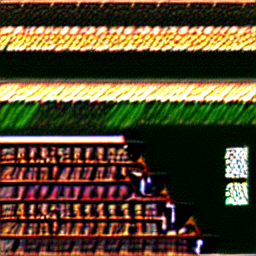

  0%|          | 0/25 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/Colab Notebooks/Modul 4 ML/dragon_gs_7.5.png


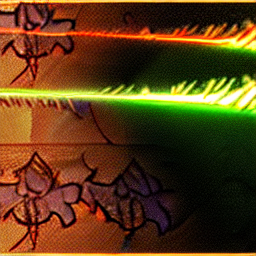

  0%|          | 0/25 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/Colab Notebooks/Modul 4 ML/dragon_gs_15.0.png


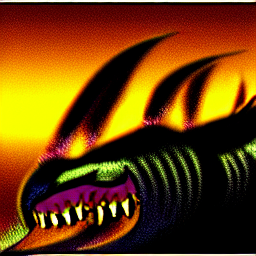


Lab 4.2 complete. Check the output images.


In [7]:
# ====
# 4. EXPERIMENT WITH PARAMETERS
# ====
prompt = "A dragon breathing fire, fantasy art"
print("\n--- Experimenting with guidance scale ---")

guidance_scales = [2.0, 7.5, 15.0]

for gs in guidance_scales:
    image = pipe(
        prompt=prompt,
        height=IMG_SIZE,
        width=IMG_SIZE,
        num_inference_steps=25,
        guidance_scale=gs,
        generator=torch.manual_seed(42),
    ).images[0]

    # Simpan ke Google Drive
    filename = os.path.join(SAVE_DIR, f"dragon_gs_{gs}.png")
    image.save(filename)

    print(f"✅ Saved: {filename}")

    # Tampilkan gambar
    display(image)

print("\nLab 4.2 complete. Check the output images.")